In [1]:
import os

xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

from functools import partial
import numpy as np
import time

from trajectory_sampler import TrajSampler as TrajSampler1

from trajectory_sampler2 import TrajSampler as TrajSampler2

import mujoco
import mujoco.mjx as mjx 
import jax
import jax.numpy as jnp

# jax.config.update("jax_enable_x64", True)
key = jax.random.PRNGKey(0)

In [2]:
num_batch = 100
num_dof = 12
num = 10
key, subkey = jax.random.split(jax.random.PRNGKey(0))

theta_init = jnp.zeros((num_batch, num_dof))
thetadot_init = jnp.zeros((num_batch, num_dof))
thetaddot_init = jnp.zeros((num_batch, num_dof))
thetadot_fin = jnp.zeros((num_batch, num_dof))
thetaddot_fin = jnp.zeros((num_batch, num_dof))

state_term = jnp.hstack((theta_init, thetadot_init, thetaddot_init, thetadot_fin, thetaddot_fin))


In [3]:

sampler1 = TrajSampler1(t_fin=1, num=num, num_batch=num_batch, num_dof=num_dof)
xi_cov1 = 10*jnp.identity(sampler1.nvar)
xi_mean1 = jnp.zeros(sampler1.nvar)
 
thetadot1, xi_samples1, _ = sampler1.generate_samples(key, xi_mean1, xi_cov1, state_term)

np.set_printoptions(precision=3, suppress=True, linewidth=120)

# print("num_dof", num_dof)
# print("thetadot",thetadot1)
# print("thedatadot",thetadot1.shape)


In [4]:

sampler2 = TrajSampler2(t_fin=1, num=num, num_batch=num_batch, num_dof=num_dof)
xi_cov2 = 10*jnp.identity(sampler2.nvar)
xi_mean2 = jnp.zeros(sampler2.nvar)
thetadot2, xi_samples2, _ = sampler2.generate_samples(key, xi_mean2, xi_cov2, state_term)

In [5]:
print("Mean_error", xi_mean1-xi_mean2)
print("COV_error", xi_cov1-xi_cov2)
print("Sample_error", xi_samples1-xi_samples2)

Mean_error [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
COV_error [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Sample_error [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/tmp/ipykernel_124385/4165080403.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


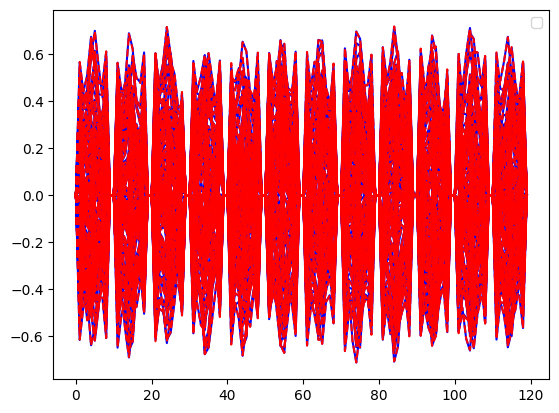

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thetadot1.T,  color='blue')
plt.plot(thetadot2.T,  color='red', linestyle='dashed')
plt.legend()
plt.show()

/tmp/ipykernel_124385/1939203614.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


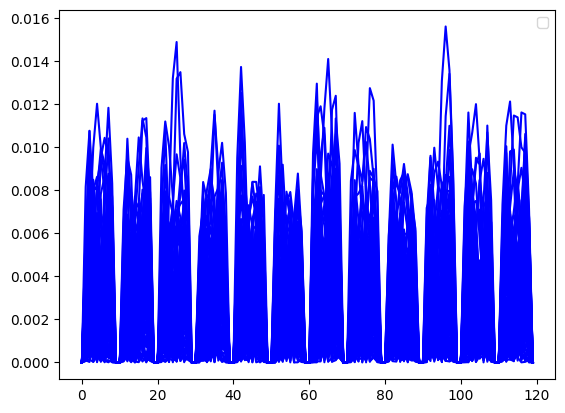

In [7]:
thetadot_error = np.abs(thetadot1 - thetadot2)
plt.figure()
plt.plot(thetadot_error.T,  color='blue')
plt.legend()
plt.show()